In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

df = pd.read_csv(r'C:\Users\vaibh\Desktop\Project Clg\project\model\Air_Quality_Forecasting.csv')
df['utc_time'] = pd.to_datetime(df['utc_time'])

df.set_index('utc_time', inplace=True)

df = df.ffill()

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data, index=df.index, columns=df.columns)


In [37]:
def create_sequences(data, time_steps=24):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps][0])  # Predicting PM2.5
    return np.array(X), np.array(y)

TIME_STEPS = 24
X, y = create_sequences(scaled_data, TIME_STEPS)

In [38]:
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=200,
                    batch_size=32,
                    callbacks=[early_stop],
                    verbose=1)


Epoch 1/200


c:\Users\vaibh\Desktop\Project Clg\project\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


222/222 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0036 - val_loss: 7.8819e-04
Epoch 2/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0015 - val_loss: 5.0399e-04
Epoch 3/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0010 - val_loss: 3.8364e-04
Epoch 4/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 8.0128e-04 - val_loss: 3.9049e-04
Epoch 5/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 8.9278e-04 - val_loss: 2.9262e-04
Epoch 6/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 7.5813e-04 - val_loss: 2.6355e-04
Epoch 7/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5.8240e-04 - val_loss: 3.0808e-04
Epoch 8/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6.1562e-04 - val_loss: 2.4119e-04
Epoch 9/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5.6769e-04 - val_loss: 2.2777e-04
Epoch 10/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5.6329e-04 - val_loss: 2.2019e-04
Epoch 11/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


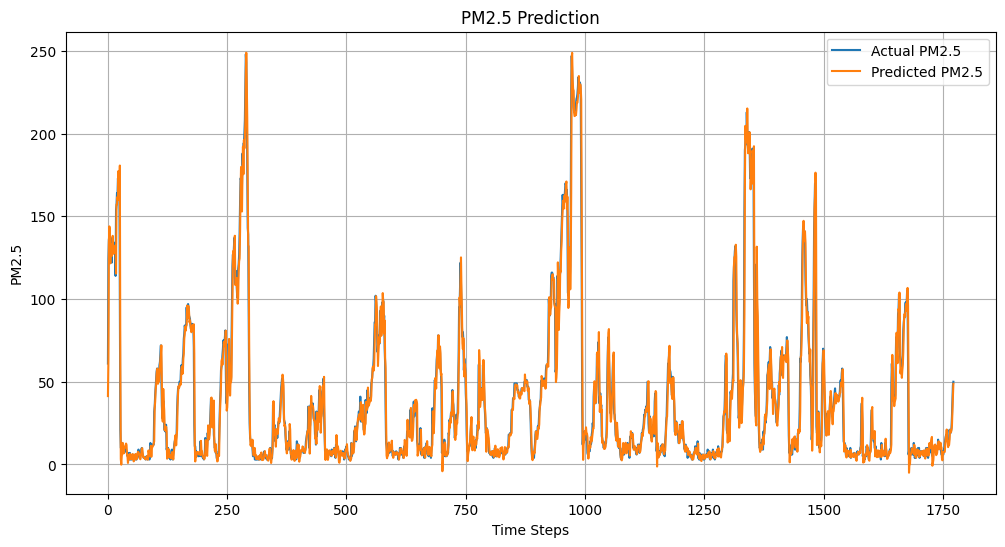

In [40]:
y_pred = model.predict(X_test)

# Inverse transform to get real PM2.5 values
pm25_scaler = MinMaxScaler()
pm25_scaler.fit(df[['PM2.5']])
y_test_inv = pm25_scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = pm25_scaler.inverse_transform(y_pred)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label='Actual PM2.5')
plt.plot(y_pred_inv, label='Predicted PM2.5')
plt.title("PM2.5 Prediction")
plt.xlabel("Time Steps")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(True)
plt.show()


In [42]:
y_pred = model.predict(X_test)

# Inverse transform the PM2.5 values (assumes PM2.5 was the first column)
pm25_scaler = MinMaxScaler()
pm25_scaler.fit(df[['PM2.5']])
y_test_inv = pm25_scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = pm25_scaler.inverse_transform(y_pred)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_inv, y_pred_inv)
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

MAE: 5.27
MSE: 90.93
RMSE: 9.54
R² Score: 0.9568


In [ ]:

y_pred = model.predict(X_test)


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(df[['PM2.5']])

y_pred_inv = scaler.inverse_transform(y_pred)


In [ ]:
import pandas as pd

predictions_df = pd.DataFrame(y_pred_inv, columns=['Predicted PM2.5'], index=df.index[-len(y_pred_inv):])

actual_values_df = pd.DataFrame(y_test_inv, columns=['Actual PM2.5'], index=df.index[-len(y_test_inv):])

results_df = pd.concat([actual_values_df, predictions_df], axis=1)

results_df.to_csv('AQI_predictions.csv')
print("Predictions saved to AQI_predictions.csv!")


Predictions saved to AQI_predictions.csv!


In [ ]:
import json
import pandas as pd


timestamps_str = df.index[-len(y_pred_inv):].strftime('%Y-%m-%d %H:%M:%S').tolist()

predictions_dict = {
    "predictions": y_pred_inv.tolist(),
    "timestamps": timestamps_str
}

# Save to JSON
with open('AQI_predictions.json', 'w') as json_file:
    json.dump(predictions_dict, json_file)

print("Predictions saved to AQI_predictions.json!")


Predictions saved to AQI_predictions.json!


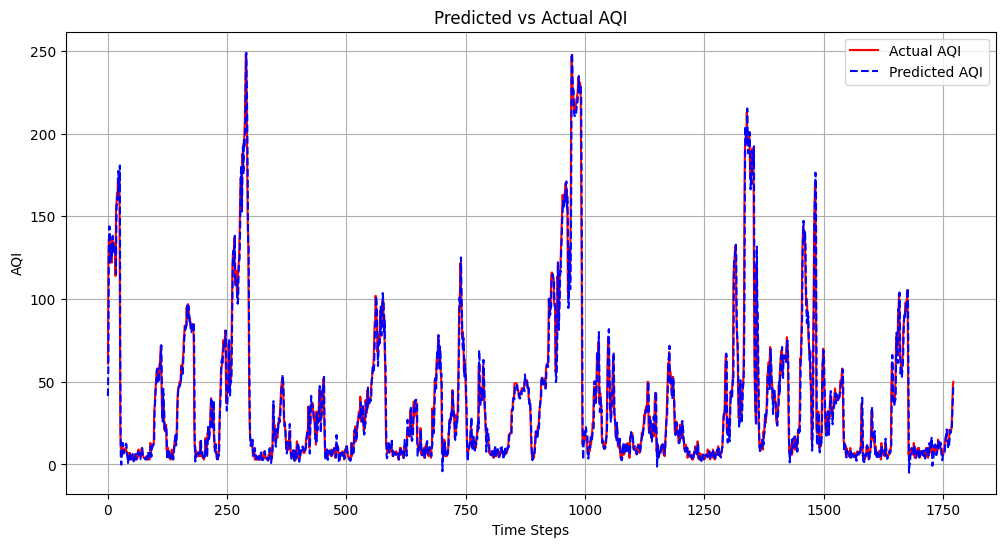

In [45]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label='Actual AQI', color='red')
plt.plot(y_pred_inv, label='Predicted AQI', color='blue', linestyle='--')
plt.title('Predicted vs Actual AQI')
plt.xlabel('Time Steps')
plt.ylabel('AQI')
plt.legend()
plt.grid(True)
plt.show()

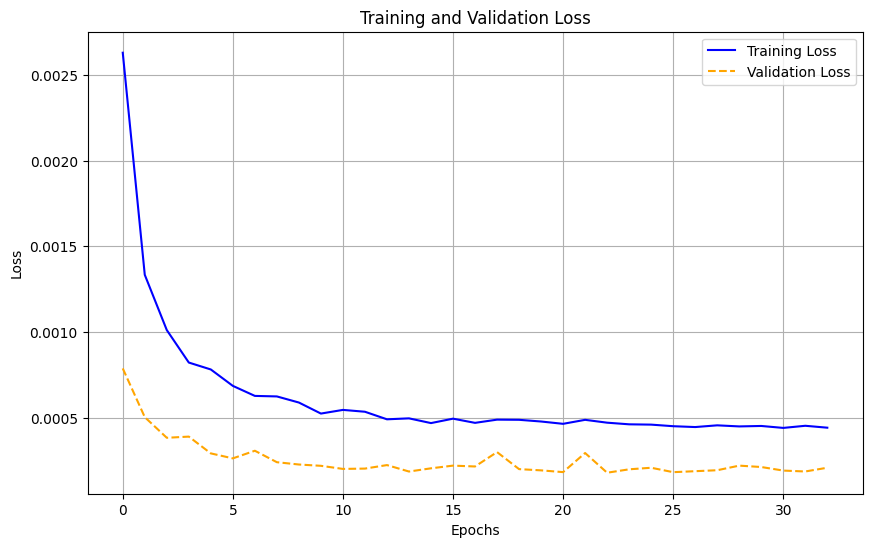

In [46]:
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

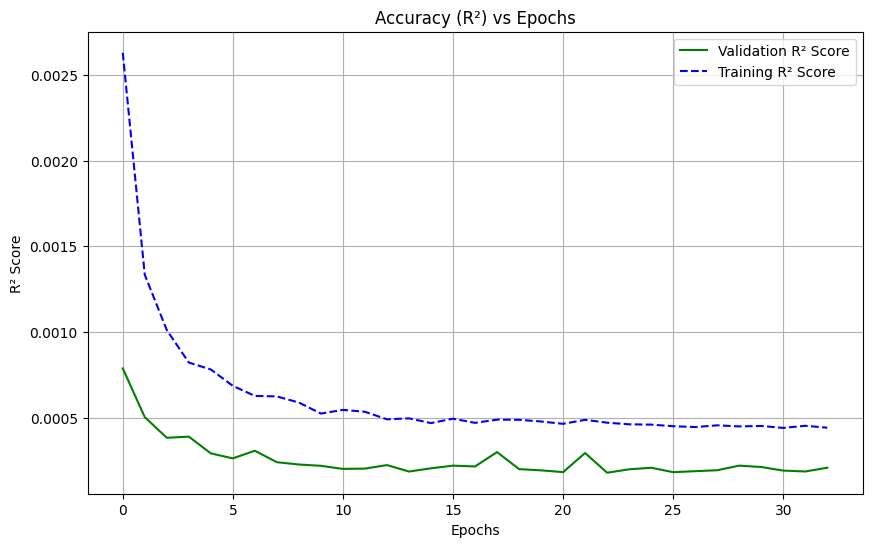

In [47]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['val_loss'], label='Validation R² Score', color='green')
plt.plot(history.history['loss'], label='Training R² Score', color='blue', linestyle='--')
plt.title('Accuracy (R²) vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('R² Score')
plt.legend()
plt.grid(True)
plt.show()

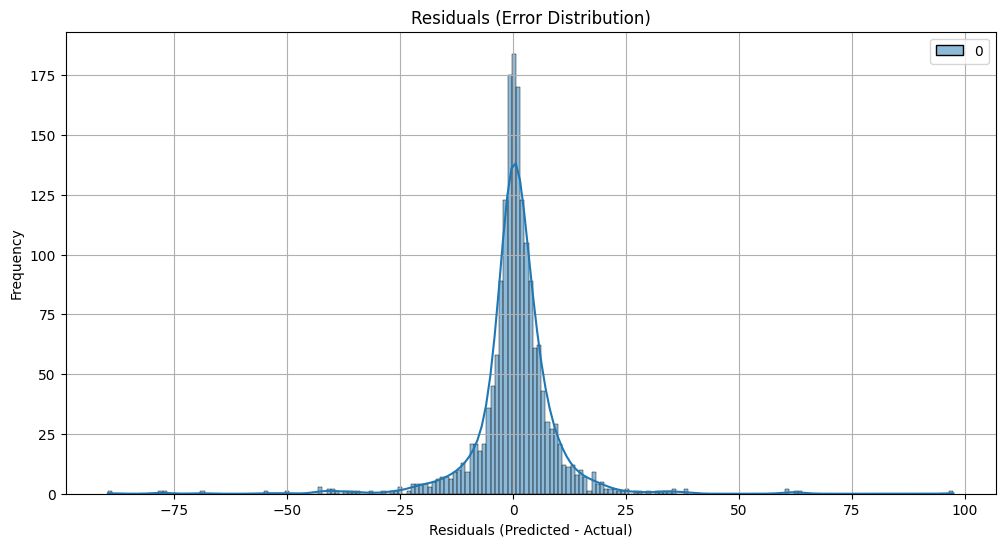

In [48]:
import seaborn as sns
import numpy as np

# Calculate residuals (errors)
residuals = y_test_inv - y_pred_inv

# Plot residuals distribution
plt.figure(figsize=(12, 6))
sns.histplot(residuals, kde=True, color='blue')
plt.title('Residuals (Error Distribution)')
plt.xlabel('Residuals (Predicted - Actual)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


C:\Users\vaibh\AppData\Local\Temp\ipykernel_22488\2577383677.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=features, y=importance_scores, palette='viridis')


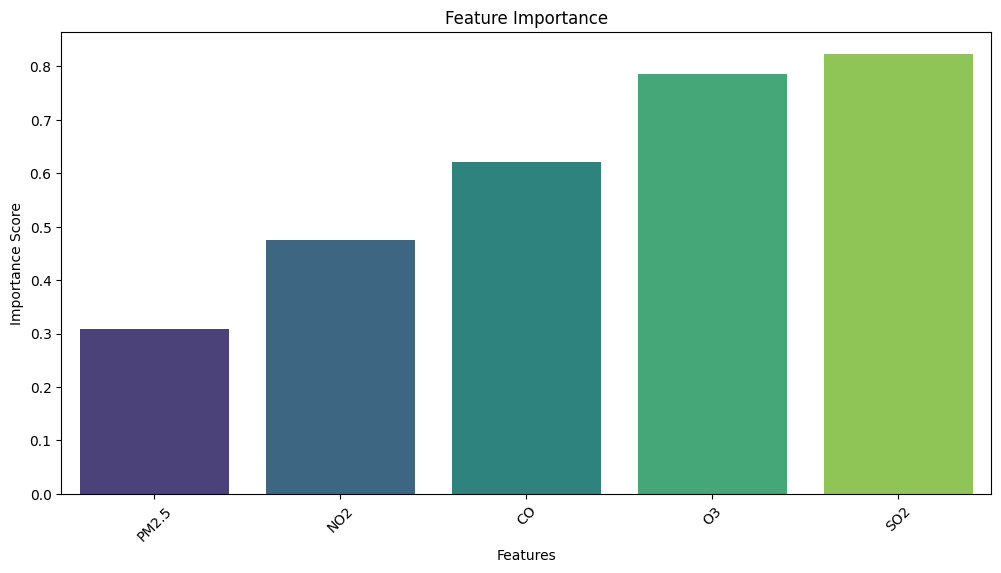

In [49]:
# Assuming we have a feature importance array (if using feature importance techniques)
features = df.columns.tolist()  # List of feature names (replace with actual columns)
importance_scores = np.random.random(len(features))  # Replace with actual importance scores

plt.figure(figsize=(12, 6))
sns.barplot(x=features, y=importance_scores, palette='viridis')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.title('Feature Importance')
plt.xticks(rotation=45)
plt.show()


C:\Users\vaibh\AppData\Local\Temp\ipykernel_22488\342117494.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette='Blues')


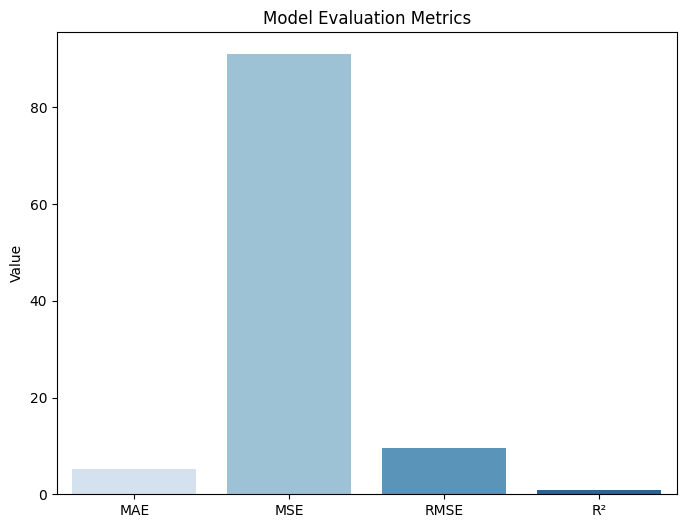

In [51]:

metrics = ['MAE', 'MSE', 'RMSE', 'R²']
values = [mae, mse, rmse, r2]

plt.figure(figsize=(8, 6))
sns.barplot(x=metrics, y=values, palette='Blues')
plt.title('Model Evaluation Metrics')
plt.ylabel('Value')
plt.show()


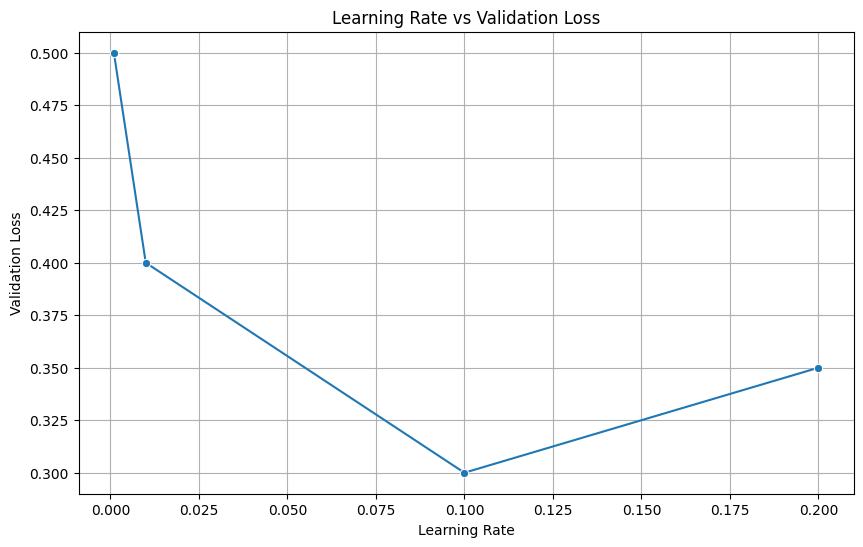

In [52]:
learning_rates = [0.001, 0.01, 0.1, 0.2]  # Replace with your learning rates
val_losses = [0.5, 0.4, 0.3, 0.35]  # Replace with corresponding validation losses

plt.figure(figsize=(10, 6))
sns.lineplot(x=learning_rates, y=val_losses, marker='o')
plt.title('Learning Rate vs Validation Loss')
plt.xlabel('Learning Rate')
plt.ylabel('Validation Loss')
plt.grid(True)
plt.show()

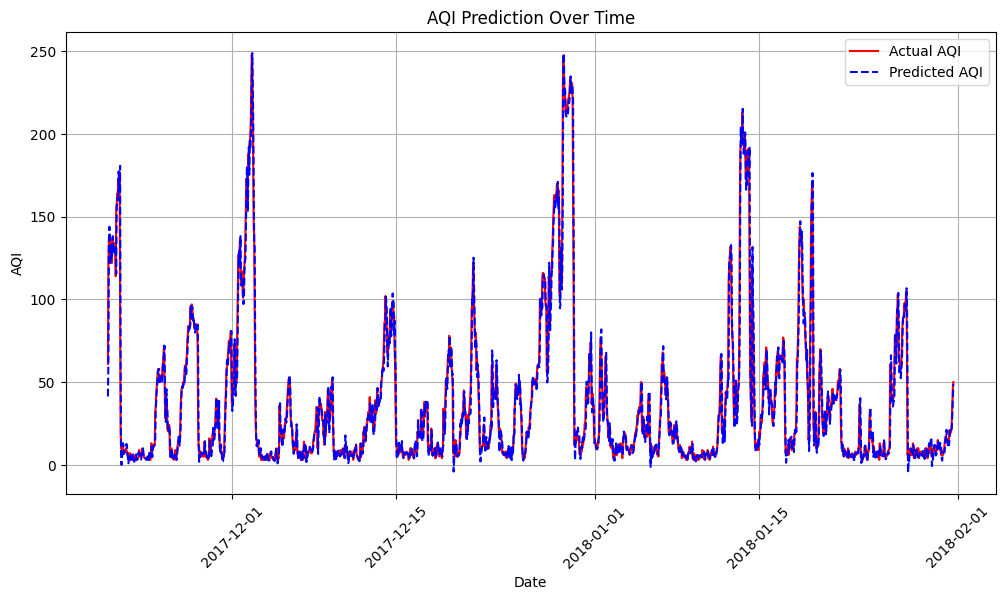

In [53]:
plt.figure(figsize=(12, 6))
plt.plot(df.index[-len(y_test_inv):], y_test_inv, label='Actual AQI', color='red')
plt.plot(df.index[-len(y_pred_inv):], y_pred_inv, label='Predicted AQI', color='blue', linestyle='--')
plt.title('AQI Prediction Over Time')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

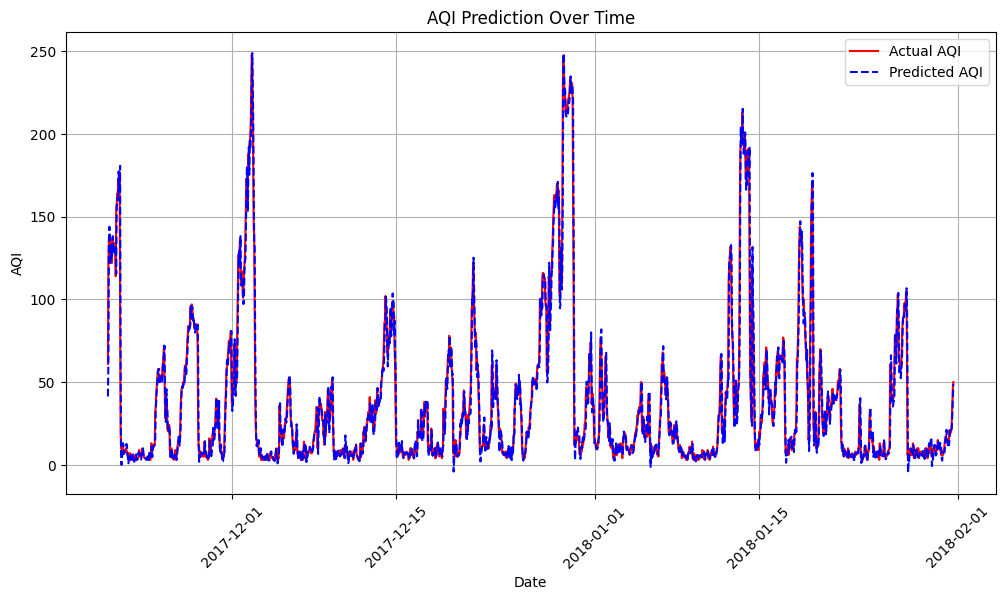

In [54]:
plt.figure(figsize=(12, 6))
plt.plot(df.index[-len(y_test_inv):], y_test_inv, label='Actual AQI', color='red')
plt.plot(df.index[-len(y_pred_inv):], y_pred_inv, label='Predicted AQI', color='blue', linestyle='--')
plt.title('AQI Prediction Over Time')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

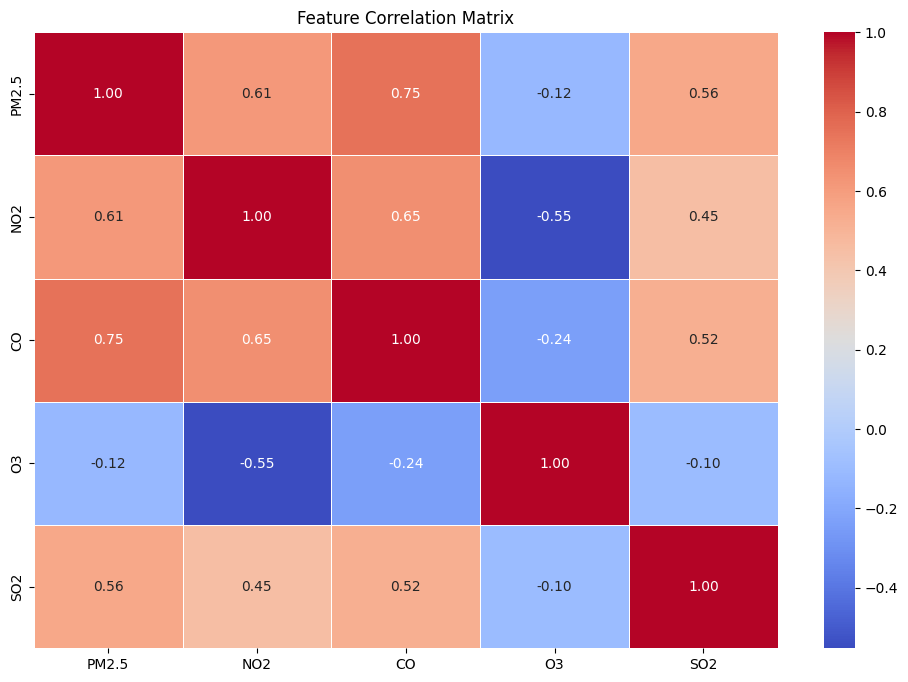

In [55]:
import seaborn as sns
import numpy as np

# Correlation matrix
correlation_matrix = df.corr()

# Plotting the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()


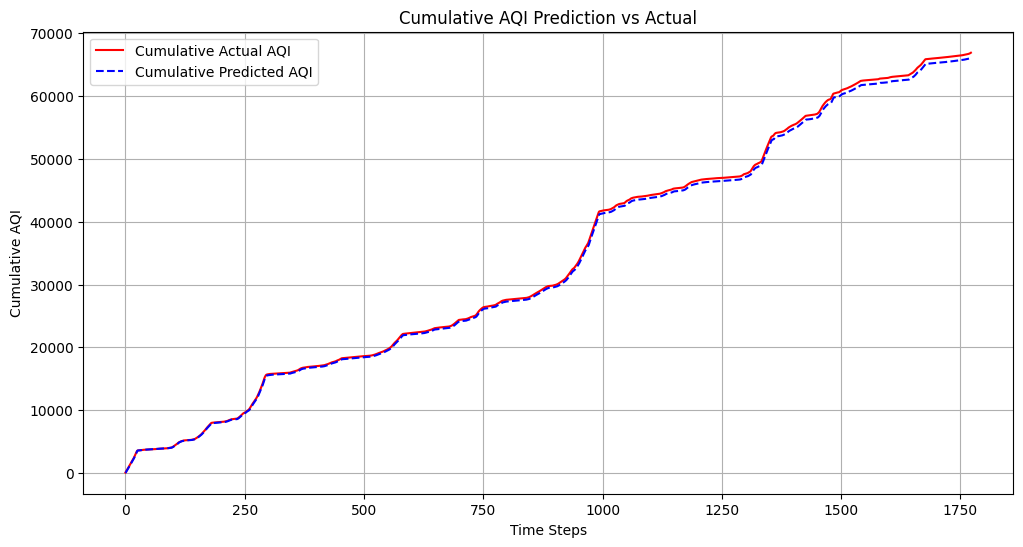

In [56]:
# Cumulative sum plot for AQI prediction
cumulative_actual = np.cumsum(y_test_inv)
cumulative_predicted = np.cumsum(y_pred_inv)

plt.figure(figsize=(12, 6))
plt.plot(cumulative_actual, label='Cumulative Actual AQI', color='red')
plt.plot(cumulative_predicted, label='Cumulative Predicted AQI', color='blue', linestyle='--')
plt.title('Cumulative AQI Prediction vs Actual')
plt.xlabel('Time Steps')
plt.ylabel('Cumulative AQI')
plt.legend()
plt.grid(True)
plt.show()


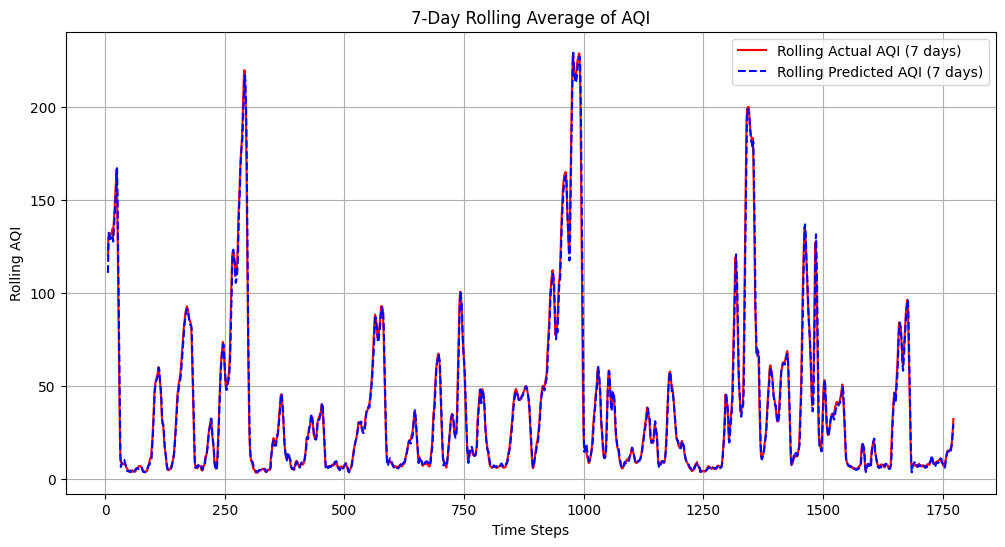

In [60]:
# Calculate 7-day rolling average
rolling_actual = pd.Series(y_test_inv.flatten()).rolling(window=7).mean()
rolling_predicted = pd.Series(y_pred_inv.flatten()).rolling(window=7).mean()

plt.figure(figsize=(12, 6))
plt.plot(rolling_actual, label='Rolling Actual AQI (7 days)', color='red')
plt.plot(rolling_predicted, label='Rolling Predicted AQI (7 days)', color='blue', linestyle='--')
plt.title('7-Day Rolling Average of AQI')
plt.xlabel('Time Steps')
plt.ylabel('Rolling AQI')
plt.legend()
plt.grid(True)
plt.show()


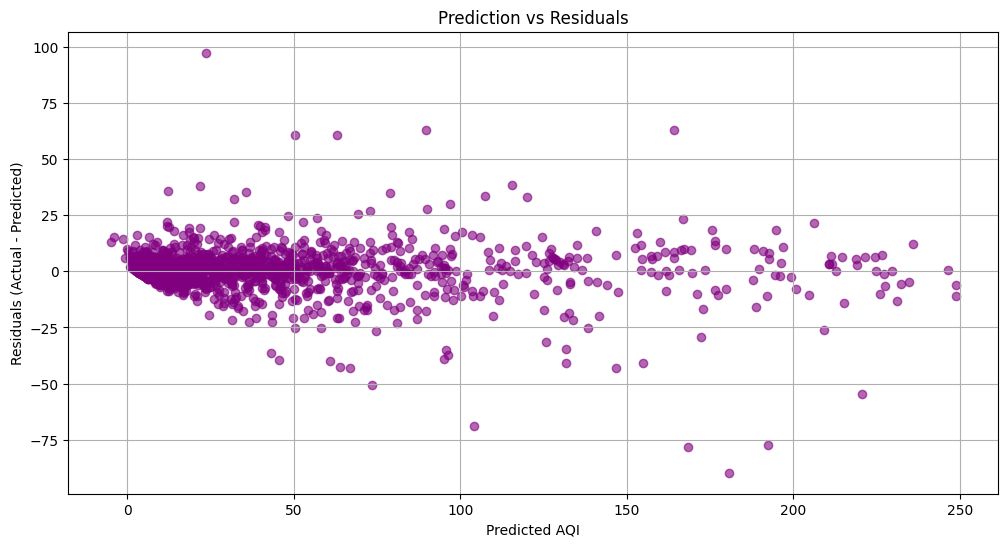

In [61]:
# Scatter plot of residuals
plt.figure(figsize=(12, 6))
plt.scatter(y_pred_inv, residuals, color='purple', alpha=0.6)
plt.title('Prediction vs Residuals')
plt.xlabel('Predicted AQI')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True)
plt.show()

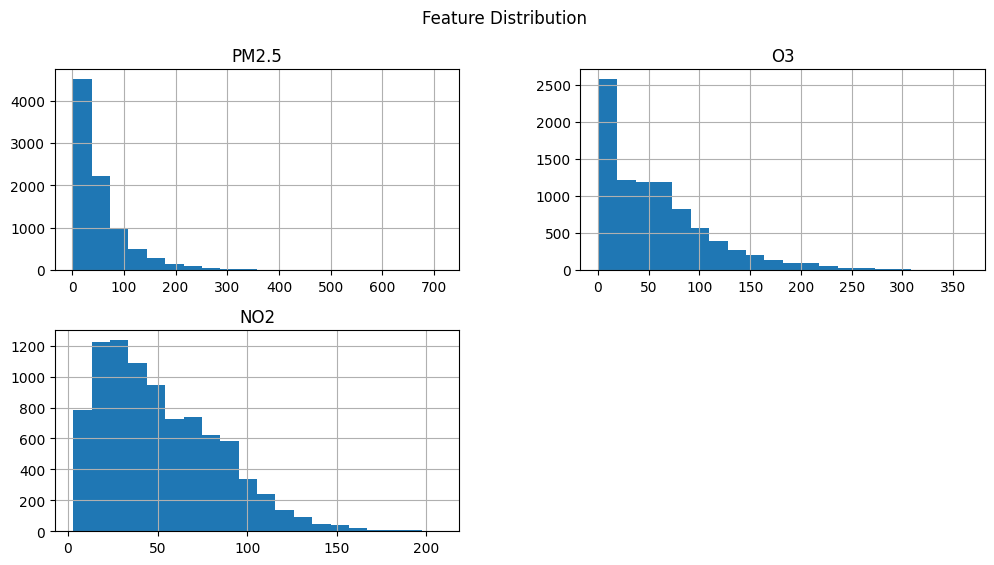

In [62]:
# Plot histogram for each feature (e.g., PM2.5, temperature, etc.)
df[['PM2.5', 'O3', 'NO2']].hist(figsize=(12, 6), bins=20)
plt.suptitle('Feature Distribution')
plt.show()

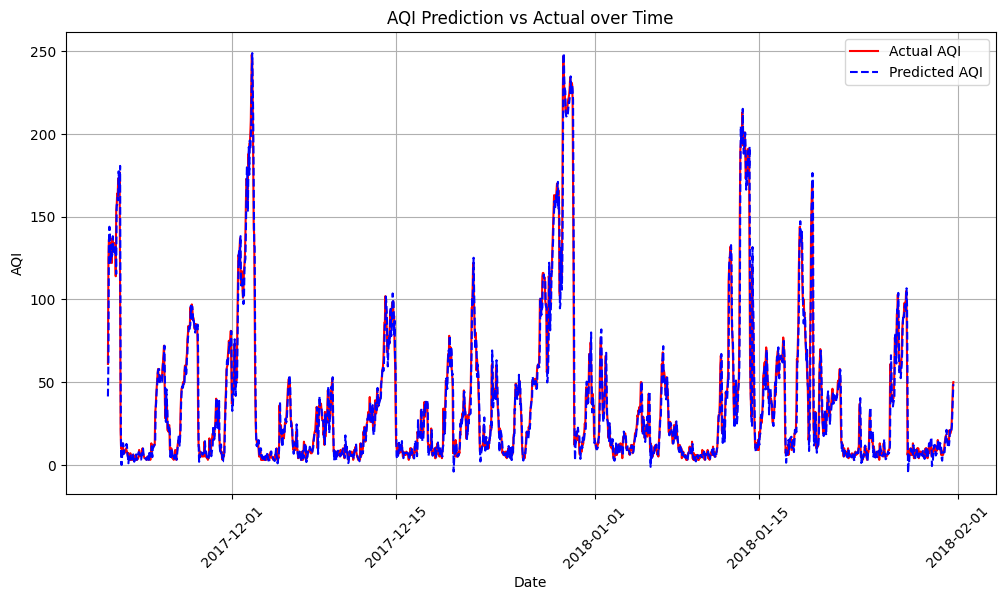

In [63]:
# Plot actual vs predicted AQI values over time (date-time x-axis)
plt.figure(figsize=(12, 6))
plt.plot(df.index[-len(y_test_inv):], y_test_inv, label='Actual AQI', color='red')
plt.plot(df.index[-len(y_pred_inv):], y_pred_inv, label='Predicted AQI', color='blue', linestyle='--')
plt.title('AQI Prediction vs Actual over Time')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()